# Pourquoi les marchés gagnent-ils *la nuit* ? 🌙
### Une anomalie boursière réelle — et pourquoi elle est plus subtile qu'elle n'en a l'air

Sur 30 ans, l'essentiel de la hausse des grandes bourses mondiales s'est accumulé **pendant que le marché était fermé** (de la clôture d'un jour à l'ouverture du lendemain). La **séance de journée** (ouverture → clôture), elle, est quasiment plate. Étrange, non ?

Ce notebook raconte l'histoire **sans jargon**. Si vous voulez la version rigoureuse (données réelles, statistiques, frais), filez vers [`02_pour_les_quants.ipynb`](02_pour_les_quants.ipynb).

> ⚠️ **Ceci n'est pas un conseil en investissement.** Outil de pédagogie et de recherche.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")


## 1. Le constat : la nuit monte, le jour stagne

Construisons un marché *jouet*, totalement honnête : chaque nuit il dérive d'un cheveu vers le haut (+3 points de base, soit +0,03 %), chaque jour d'un cheveu vers le bas, et **tout le reste est du bruit pur — aucune fraude, aucun complot**. Que donne la décomposition nuit / jour ?

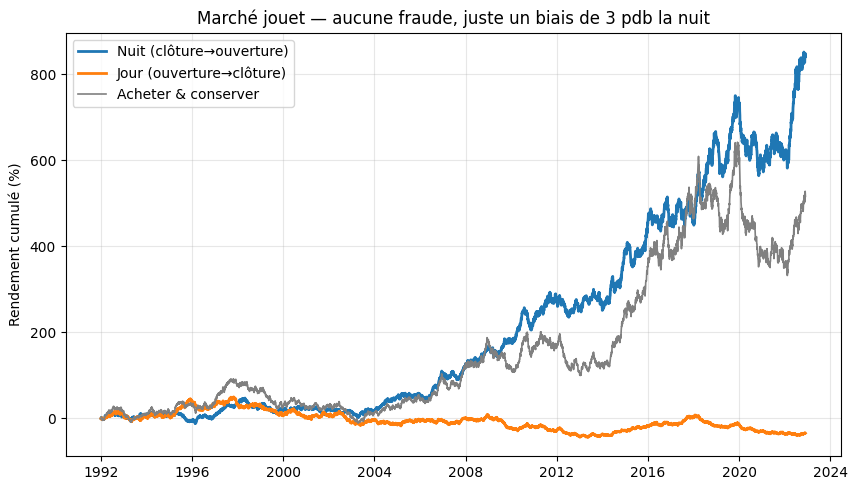

Nuit cumulée : +840%   Jour cumulé : -35%


In [2]:
from overnight import decompose, diagnostics

ohlc = diagnostics.synthetic_ohlc(overnight_bias_bps=3, intraday_bias_bps=-1, seed=0)
dec = decompose.decompose(ohlc)

ax = plt.subplot()
ax.plot(dec.index, dec['cum_overnight']*100, label='Nuit (clôture→ouverture)', lw=2)
ax.plot(dec.index, dec['cum_intraday']*100, label='Jour (ouverture→clôture)', lw=2)
ax.plot(dec.index, dec['cum_close_close']*100, label='Acheter & conserver', color='grey', lw=1.2)
ax.set_title('Marché jouet — aucune fraude, juste un biais de 3 pdb la nuit')
ax.set_ylabel('Rendement cumulé (%)'); ax.legend(); ax.grid(alpha=.3)
plt.show()
s = decompose.summary(dec)
print(f"Nuit cumulée : {s.loc['overnight','cum_return']*100:+.0f}%   "
      f"Jour cumulé : {s.loc['intraday','cum_return']*100:+.0f}%")

**On a reproduit le motif de Knuteson sans la moindre manipulation.** Un minuscule biais constant, répété ~250 nuits par an pendant 32 ans, suffit. La nuit *semble* magique. Gardez cette idée : un tout petit décalage, répété des milliers de fois, devient énorme. C'est notre premier piège.

## 2. Piège n°1 — l'échelle ment (la magie des intérêts composés)

Les graphiques de l'article sont en **échelle logarithmique**, où l'on voit vite « des milliards de % ». Mais d'où vient ce chiffre vertigineux ? Pas d'une fraude : de la **composition**. Regardez ce que devient un simple biais constant selon sa taille et l'horizon :

In [3]:
table = diagnostics.compounding_table()
diagnostics.format_compounding(table)

,~10y,~20y,~32y
1 bps/night,+29%,+66%,+124%
5 bps/night,+252%,"+1,142%","+5,532%"
10 bps/night,"+1,141%","+15,308%","+316,420%"
30 bps/night,"+189,724%",+360M%,+3.1tn%


Un biais de **1 point de base par nuit** — totalement innocent, indétectable — compose à trois chiffres sur 30 ans. À 30 pdb, on atteint des *billions* de pourcents. **L'explosion vient de l'exposant, pas d'un complot.** Toute magnitude spectaculaire affichée en log doit d'abord passer ce test de bon sens.

## 3. Piège n°2 — des données sales fabriquent le signal

Les données gratuites (Yahoo) ajustent mal certains *splits* et dividendes, surtout sur les marchés émergents. Une poignée de prix corrompus suffit à **déplacer mécaniquement du rendement du jour vers la nuit**. Démonstration sur un marché totalement plat (zéro biais) où l'on salit 3 cours :

In [4]:
flat = diagnostics.synthetic_ohlc(overnight_bias_bps=0, intraday_bias_bps=0, seed=1)
propre = decompose.decompose(flat)
sale = decompose.decompose(diagnostics.inject_split_artifact(flat, factor=1.5))
print(f"Nuit cumulée  AVANT : {propre['cum_overnight'].iloc[-1]*100:+.1f}%")
print(f"Nuit cumulée  APRÈS : {sale['cum_overnight'].iloc[-1]*100:+.1f}%   (3 cours salis)")
flags = diagnostics.flag_suspicious_returns(sale)
print(f"\nLe détecteur automatique repère {len(flags)} jour(s) suspect(s) :")
flags[['r_overnight','r_intraday']]

Nuit cumulée  AVANT : -56.0%
Nuit cumulée  APRÈS : +48.6%   (3 cours salis)

Le détecteur automatique repère 3 jour(s) suspect(s) :


,r_overnight,r_intraday
1999-09-23,0.508,-0.337
2015-03-09,0.504,-0.335
2007-06-15,0.493,-0.341


Trois erreurs de données, et la « performance nuit » passe du rouge au vert vif. C'est exactement le mécanisme derrière les chiffres délirants de certains marchés émergents dans l'article. **Avant de crier au scandale, vérifiez vos données.**

## 4. Piège n°3 — les frais effacent le gain

Admettons que l'effet nuit soit réel (il l'est en partie). Peut-on le *trader* ? La stratégie « acheter à la clôture, vendre à l'ouverture » paie l'écart achat/vente **deux fois par jour, ~250 jours par an**. Regardons ce qu'il reste quand on soustrait des frais réalistes :

In [5]:
from overnight import backtest
sweep = backtest.cost_sweep(dec, roundtrip_bps=(0,1,2,3,5,8))
vue = sweep.copy()
vue['cagr_net'] = (vue['cagr_net']*100).map('{:+.2f}%'.format)
vue['sharpe_net'] = vue['sharpe_net'].map('{:+.2f}'.format)
vue['max_drawdown'] = (vue['max_drawdown']*100).map('{:.0f}%'.format)
vue.columns = ['Rendement annuel net', 'Sharpe net', 'Pire perte']
vue.index.name = 'Coût aller-retour (pdb)'
vue

,Rendement annuel net,Sharpe net,Pire perte
Coût aller-retour (pdb),,,
0,+7.25%,+0.68,-31%
1,+4.59%,+0.45,-39%
2,+1.98%,+0.23,-48%
3,-0.55%,+0.01,-61%
5,-5.44%,-0.44,-87%
8,-12.33%,-1.11,-99%


À **0 frais**, le Sharpe est correct (~0,7). À un coût réaliste de **5 points de base** l'aller-retour, le gain devient **négatif**. C'est précisément le sort des ETF « night effect » NSPY et NIWM : lancés en juin 2022, **liquidés en août 2023** après une forte sous-performance.

> *Une stratégie magnifique sur le papier ne vaut pas plus que le papier tant qu'elle n'a pas payé les coûts réels d'exécution.*

## En résumé

| | |
|---|---|
| ✅ **Le fait est réel** | la nuit a bien sur-performé le jour, sur des décennies |
| ⚠️ **Mais les chiffres sont gonflés** | composition + échelle log + données sales |
| ❌ **Et difficilement exploitable** | les frais effacent l'avantage |

L'anomalie nuit/jour est un superbe cas d'école : **réelle, fascinante, mais à manier avec rigueur**. Pour la version chiffrée sur données réelles — test Chine, artefacts, statistiques, bêta vs alpha — voir [`02_pour_les_quants.ipynb`](02_pour_les_quants.ipynb).